# Multipole Utilities

This notebook demonstrates the multipole field utilities:
- `synthesize_field`: compute transverse magnetic fields from multipole coefficients
- `decompose_field`: recover multipole coefficients from azimuthal field measurements
- `scalar_error`: compute normalized RMS field error between two field distributions

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from pmd_beamphysics.fields.multipole import synthesize_field, decompose_field, scalar_error

## Field Synthesis

Synthesize a quadrupole field and visualize it as a quiver plot.

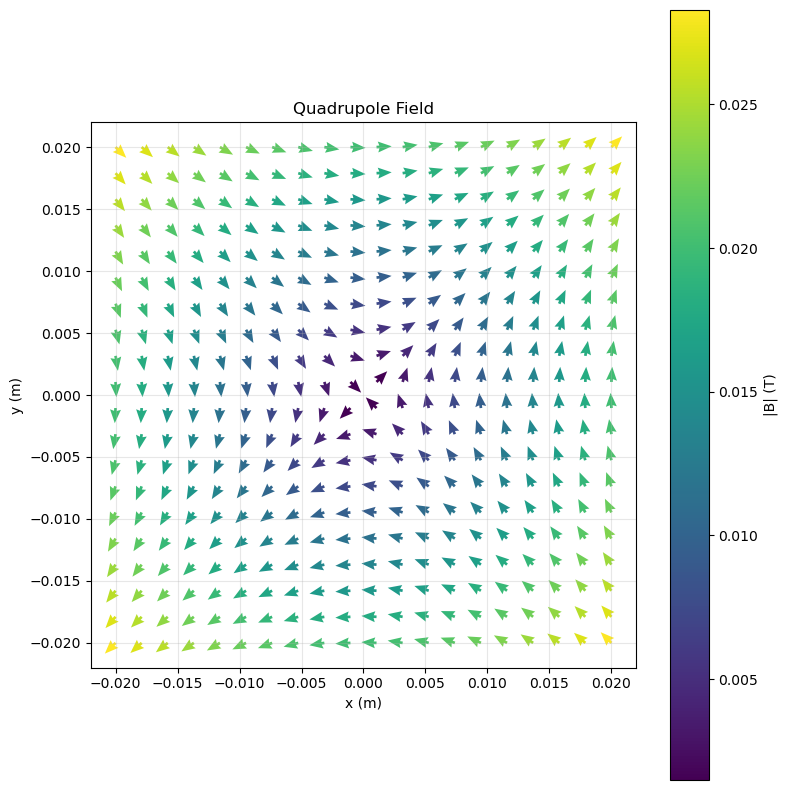

In [4]:
multipoles = [
    (0.0, 0.0),   # Dipole
    (1.0, 0.0),   # Quadrupole
    (0.0, 0.0),   # Sextupole
]

# Create a grid of points
x = np.linspace(-0.02, 0.02, 20)
y = np.linspace(-0.02, 0.02, 20)
X, Y = np.meshgrid(x, y)

# Calculate fields at each grid point
B_x, B_y = synthesize_field(X, Y, multipoles)

# Normalize for uniform arrow lengths
B_mag = np.sqrt(B_x**2 + B_y**2)
B_x_norm = np.divide(B_x, B_mag, out=np.zeros_like(B_x), where=B_mag != 0)
B_y_norm = np.divide(B_y, B_mag, out=np.zeros_like(B_y), where=B_mag != 0)

fig, ax = plt.subplots(figsize=(8, 8))
ax.quiver(X, Y, B_x_norm, B_y_norm, B_mag,
          cmap='viridis', width=0.005, headwidth=4, headlength=5)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('Quadrupole Field')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.colorbar(ax.collections[0], ax=ax, label='|B| (T)')
plt.tight_layout()
plt.show()

## Field Decomposition

Generate synthetic azimuthal field measurements from known multipoles, then recover the coefficients with `decompose_field`.

In [5]:
ground_truth = [
    (1.0, 0.5),
    (10.0, -5.0),
    (100.0, 60.0),
]

r0 = 0.01  # measurement radius (m)
phi_samples = np.linspace(0, 2 * np.pi, 72, endpoint=False)

# Synthesize B_phi at each sample angle
data = []
for phi in phi_samples:
    x = r0 * np.cos(phi)
    y = r0 * np.sin(phi)
    Bx, By = synthesize_field(x, y, ground_truth)
    B_phi = -Bx * np.sin(phi) + By * np.cos(phi)
    data.append((phi, B_phi))

recovered = decompose_field(data, r0, nmax=2)

print('Ground truth multipoles:')
for n, (Bn, Sn) in enumerate(ground_truth):
    print(f'  n={n}: B_{n} = {Bn:8.3f} T/m^{n},  S_{n} = {Sn:8.3f} T/m^{n}')

print('\nRecovered multipoles:')
for n, (Bn, Sn) in enumerate(recovered):
    print(f'  n={n}: B_{n} = {Bn:8.3f} T/m^{n},  S_{n} = {Sn:8.3f} T/m^{n}')

print('\nErrors:')
for n in range(len(ground_truth)):
    dB = abs(recovered[n][0] - ground_truth[n][0])
    dS = abs(recovered[n][1] - ground_truth[n][1])
    print(f'  n={n}: dB_{n} = {dB:.2e} T/m^{n},  dS_{n} = {dS:.2e} T/m^{n}')

Ground truth multipoles:
  n=0: B_0 =    1.000 T/m^0,  S_0 =    0.500 T/m^0
  n=1: B_1 =   10.000 T/m^1,  S_1 =   -5.000 T/m^1
  n=2: B_2 =  100.000 T/m^2,  S_2 =   60.000 T/m^2

Recovered multipoles:
  n=0: B_0 =    1.000 T/m^0,  S_0 =    0.500 T/m^0
  n=1: B_1 =   10.000 T/m^1,  S_1 =   -5.000 T/m^1
  n=2: B_2 =  100.000 T/m^2,  S_2 =   60.000 T/m^2

Errors:
  n=0: dB_0 = 0.00e+00 T/m^0,  dS_0 = 0.00e+00 T/m^0
  n=1: dB_1 = 0.00e+00 T/m^1,  dS_1 = 8.88e-16 T/m^1
  n=2: dB_2 = 5.68e-14 T/m^2,  dS_2 = 4.26e-14 T/m^2


## Scalar Error

Compute the normalized RMS field error between a design quadrupole and one with an added octupole error.

In [6]:
from functools import partial

design_multipoles = [(0.0, 0.0), (10.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
error_multipoles = [(0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (80.0, 0.0)]

actual_multipoles = [
    (d[0] + e[0], d[1] + e[1])
    for d, e in zip(design_multipoles, error_multipoles)
]

B_design = partial(synthesize_field, multipoles=design_multipoles)
B_actual = partial(synthesize_field, multipoles=actual_multipoles)

r0 = 0.010
error = scalar_error(B_actual, B_design, r0)
print(f'dB/B = {error}')

dB/B = 0.0001333333333333248
